# Web Traffic

## Set Up

### Import Libraries

In [1]:
import warnings
import os
import sys
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import zipfile

import pprint
from IPython.display import display
import datetime
import statsmodels.api as sm

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf , plot_accf_grid
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR
from tqdm import tqdm
from joblib import Parallel, delayed
import warnings

from scipy.interpolate import UnivariateSpline

### Import Data

In [2]:
data = pd.read_csv('train_2.csv')

In [3]:
df = pd.DataFrame(data)
df.set_index('Page', inplace=True)
df = df.loc['Inside_Out_(2015_film)_en.wikipedia.org_all-access_all-agents']

In [5]:
df.index = pd.to_datetime(df.index)

In [6]:
train_end_range = round(365*2)
test_end_range = round(60)
df_train = df.iloc[0:train_end_range]
df_test = df.iloc[train_end_range:train_end_range+test_end_range]

In [7]:
weekly_df = df.resample('W').sum()
weekly_df_train = df_train.resample('W').sum()
weekly_df_test = df_test.resample('W').sum()

### Examine Data Statistics

In [8]:
df_train.info()

<class 'pandas.Series'>
DatetimeIndex: 730 entries, 2015-07-01 to 2017-06-29
Series name: Inside_Out_(2015_film)_en.wikipedia.org_all-access_all-agents
Non-Null Count  Dtype  
--------------  -----  
730 non-null    float64
dtypes: float64(1)
memory usage: 11.4 KB


In [9]:
df_train.describe()

count      730.000000
mean     10358.872603
std       9560.811002
min       2746.000000
25%       4068.500000
50%       6204.000000
75%      14977.500000
max      68182.000000
Name: Inside_Out_(2015_film)_en.wikipedia.org_all-access_all-agents, dtype: float64

## Data Exploration

### All Dates

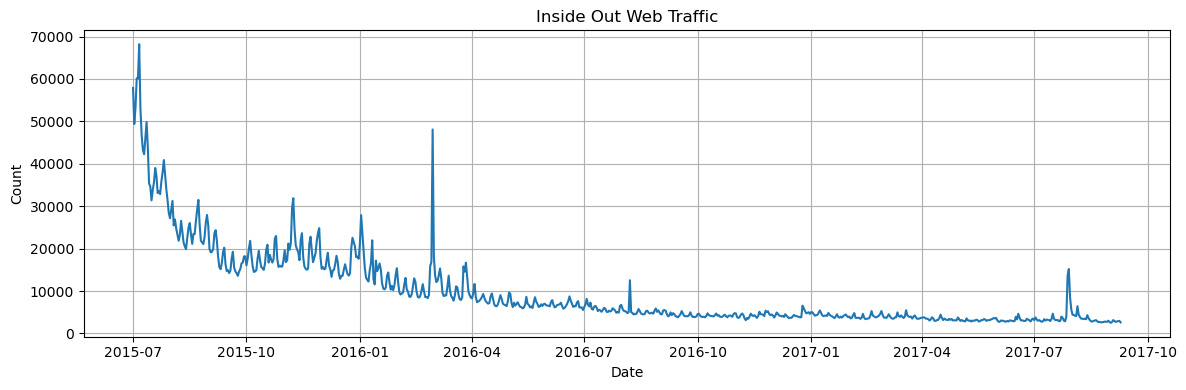

In [10]:
fig, ax = plt.subplots(figsize = (12,4))

plt.plot(df)
plt.title('Inside Out Web Traffic')
plt.ylabel('Count')
plt.xlabel('Date')
plt.grid()
# plt.ylim((0,4000))

plt.tight_layout()
plt.show()

### 1 Month

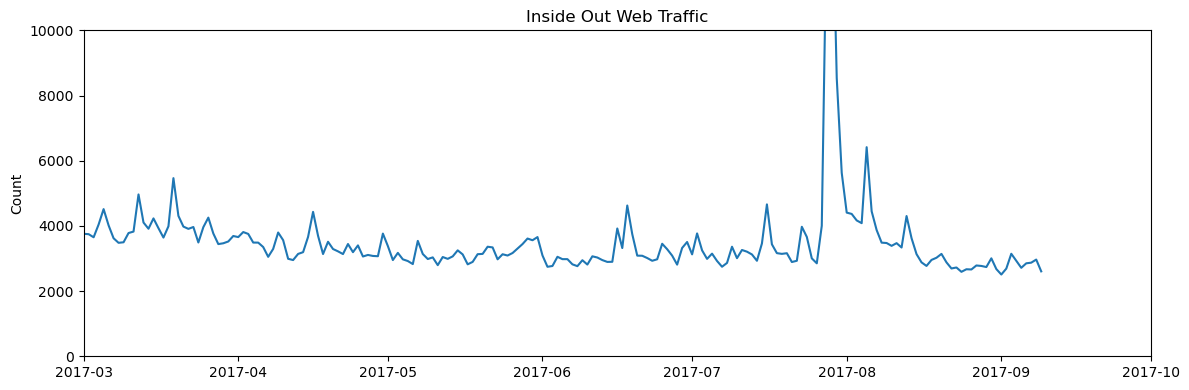

In [11]:
fig, ax = plt.subplots(figsize = (12,4))

plt.plot(df)
plt.title('Inside Out Web Traffic')
plt.ylabel('Count')
plt.ylim(0,10000)
plt.xlim(datetime.datetime(2017, 3, 1), datetime.datetime(2017, 10, 1))

plt.tight_layout()
plt.show()

### Inside Out Web Traffic Analysis

##### 1 Day

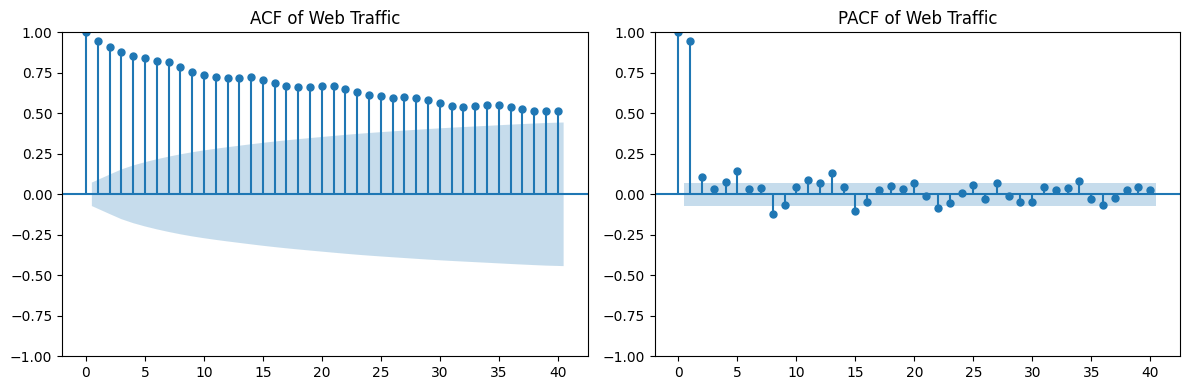

In [33]:
fig, (ax1,ax2) = plt.subplots(1 , 2, figsize=(12, 4))
plot_acf(df_train, lags = 40, ax = ax1, title = 'ACF of Web Traffic')
plot_pacf(df_train, lags = 40, ax = ax2, title = 'PACF of Web Traffic')

plt.tight_layout()
plt.show()

In [15]:
max_ar=list(range(0,2+1))
max_ma=list(range(0,2+1))
max_sar = list(range(0,1+1))
max_sma = list(range(0,1+1))
shape = (len(max_ar), len(max_ma), len(max_sar), len(max_sma))

aic_matrix = np.full(shape, np.inf)
aicc_matrix = np.full(shape, np.inf)
bic_matrix = np.full(shape, np.inf)

total = shape[0] * shape[1] * shape[2] * shape[3]
progress = tqdm(total=total, desc="ARIMA Grid Search")

for p in max_ar:
    for q in max_ma:
        for P in max_sar:
            for Q in max_sma:
                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        fit_result = SARIMAX(
                            df_train,
                            order=(p, 1, q),
                            seasonal_order = (P,1,Q,7),
                            enforce_stationarity = True,
                            enforce_invertibility = True
                        ).fit()

                    k = len(fit_result.params)
                    n = len(df_train)
                    aicc = fit_result.aic + (2 * k**2 + 2 * k) / (n - k - 1)

                    aic_matrix[p, q, P, Q] = fit_result.aic
                    aicc_matrix[p, q, P, Q] = aicc
                    bic_matrix[p, q, P, Q] = fit_result.bic

                except Exception:

                    pass

                progress.update(1)

progress.close()
min_idx = np.unravel_index(np.argmin(aicc_matrix), aicc_matrix.shape)

p_best = min_idx[0]
q_best = min_idx[1]
P_best = min_idx[2]
Q_best = min_idx[3]
best_value = aicc_matrix[min_idx]

print(p_best,
Q_best ,
P_best,
Q_best,
best_value)

ARIMA Grid Search: 100%|██████████| 60/60 [01:03<00:00,  1.06s/it]

1 1 1 1 13114.06214137113


In [ ]:
sarima_bike_north = SARIMAX(
                            df_train['bike_north_harmonic_gam_resid'],
                            order=(2, 0, 1),
                            seasonal_order = (1,0,1,24),
                            enforce_stationarity = True,
                            enforce_invertibility = True
                        ).fit()

df_train['bike_north_harmonic_gam_sarima_resid'] = sarima_bike_north.resid

In [ ]:
df_train['SARIMA_resid'] =